### Supernova distances and redshifts (part 2 and 3)

### Part 2 (start in class)

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the `kernels` submodule of [sklearn.gaussian_process](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process)
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

*Note*. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

In [30]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

Let's try to fit our datat using GPR with different kernels:

Text(0.5, 1.0, 'RBF * Constant Kernel')

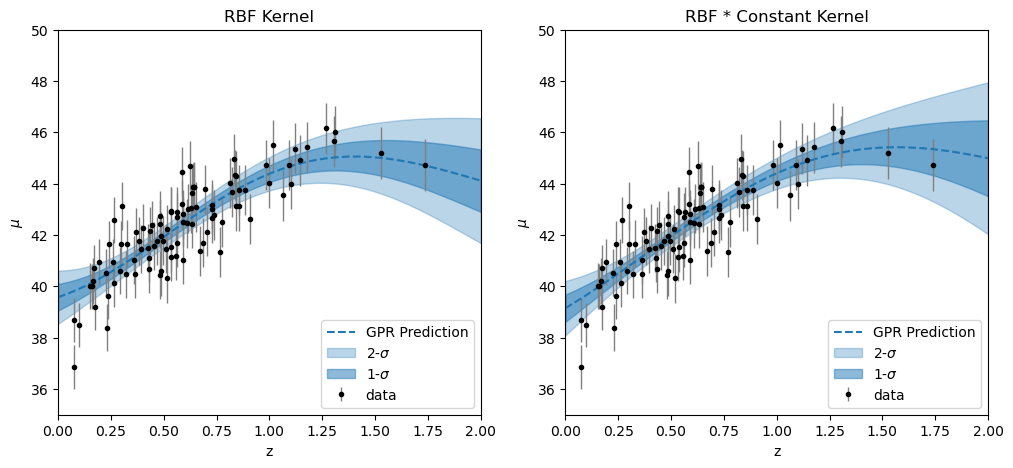

In [31]:
kernel = [kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3)), \
        kernels.RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3)) * kernels.ConstantKernel(constant_value=1.0, constant_value_bounds=(1e-3, 1e3))]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

z_grid = np.linspace(0.0, 2.0, 1000)

for ker in kernel:
    gpr = GaussianProcessRegressor(kernel=ker, alpha=dmu**2, normalize_y=True)
    gpr.fit(z_sample[:, None], mu_sample)
    mu_pred, mu_std = gpr.predict(z_grid[:, None], return_std=True)

    ax[kernel.index(ker)].errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
    ax[kernel.index(ker)].plot(z_grid, mu_pred, label="GPR Prediction", color="C0", linestyle='--')
    ax[kernel.index(ker)].fill_between(z_grid, mu_pred-2*mu_std, mu_pred+2*mu_std, alpha = 0.3, color="C0", label = r'2-$\sigma$')
    ax[kernel.index(ker)].fill_between(z_grid, mu_pred-mu_std, mu_pred+mu_std, alpha = 0.5, color="C0", label = r'1-$\sigma$')
    ax[kernel.index(ker)].set_xlabel("z")
    ax[kernel.index(ker)].set_ylabel("$\mu$")
    ax[kernel.index(ker)].set_xlim(0,2)
    ax[kernel.index(ker)].set_ylim(35,50)
    ax[kernel.index(ker)].legend(loc='lower right')
ax[0].set_title("RBF Kernel")
ax[1].set_title("RBF * Constant Kernel")

We can see that in both cases at large and low z, where we have few observations, the 1-$\sigma$ and 2-$\sigma$ contours apper to be broader with respect to where we have more datapoints.

Let's try to find the best hyperparameters throgh cross validation:

In [32]:
kernel = kernels.RBF() * kernels.ConstantKernel(constant_value_bounds=(1e-3, 1e3))

gpr = GaussianProcessRegressor(kernel=kernel, alpha=np.mean(dmu**2), normalize_y=True)
param_grid = {'kernel__k1__length_scale': np.linspace(0.1, 5, 20),
            'kernel__k2__constant_value': np.linspace(0.1, 5, 20)}
K = 5
grid_search = GridSearchCV(gpr, param_grid, cv = K)
grid_search.fit(z_sample[:,None], mu_sample)
best_ls = grid_search.best_params_['kernel__k1__length_scale']
best_cv = grid_search.best_params_['kernel__k2__constant_value']
best_kernel = kernels.RBF(length_scale=best_ls) * kernels.ConstantKernel(constant_value=best_cv)
best_gpr = GaussianProcessRegressor(kernel=best_kernel, alpha=np.mean(dmu)**2, normalize_y=True)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'kernel__k1__length_scale': 1.6473684210526318, 'kernel__k2__constant_value': 4.484210526315789}


(35.0, 50.0)

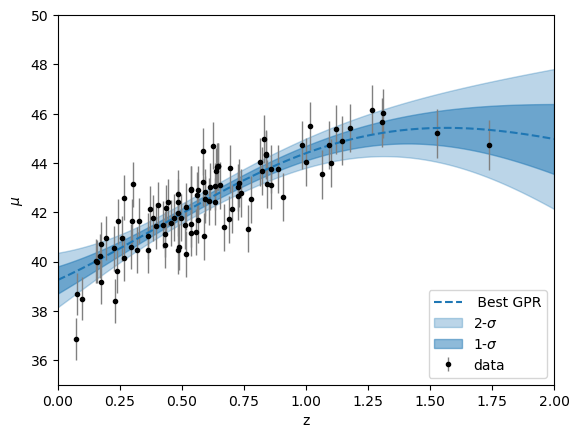

In [33]:
best_gpr.fit(z_sample[:,None], mu_sample)
mu_pred, mu_std = best_gpr.predict(z_grid[:, None], return_std=True)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z_grid, mu_pred, label=" Best GPR", color="C0", linestyle='--')
plt.fill_between(z_grid, mu_pred-2*mu_std, mu_pred+2*mu_std, alpha = 0.3, color = 'C0', label = r'2-$\sigma$')
plt.fill_between(z_grid, mu_pred-mu_std, mu_pred+mu_std, alpha = 0.5, color = 'C0', label = r'1-$\sigma$')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

Using this best GPR fit, we can also generate a new set of $\mu$:

(35.0, 50.0)

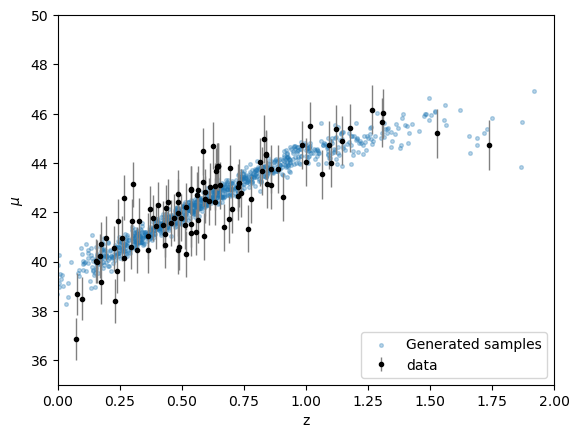

In [34]:
z_grid = np.linspace(z_sample.min(), z_sample.max(), 1000)

kde = KernelDensity(bandwidth=0.1, kernel='gaussian')
kde.fit(z_sample[:, None])

N = 10*len(z_sample)

new_z = kde.sample(N).flatten()

mu_new=[]
for z in new_z:    
    mu, sigma = best_gpr.predict([[z]], return_std=True)
    mu_new.append(np.random.normal(loc=mu, scale=sigma))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.scatter(new_z, mu_new, s=7, alpha=0.3, label='Generated samples')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

### Part 3

We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts.

For the case of supernovae we have do have physical theory which is $\Lambda$ CDM. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift z. The answer is:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$

- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$
- It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:
    - Set up a Bayesian framework and use MCMC. 
    - Set up a fully-connected neural network (see end of the class).

- What are the measured value of $H_0$ and $\Omega_m$. What's they errors? Are they correlated?
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)

In [35]:
import scipy
from scipy import stats
from scipy.integrate import quad
import emcee
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc

First of all, let's polt out theretical model ($\Lambda$-CDM) with the fiducial values $H_0 = 67.8$ and $\Omega _m = 0.308$:

In [36]:
c = scipy.constants.c/1000 # speed of light in km/s

def mu_LCDM(z, H_0, Omega_m):

    def integral(zp):
        return 1.0 / np.sqrt(Omega_m*(1+zp)**3 + (1-Omega_m))

    mu = np.zeros_like(z, dtype=float)
    for i, zi in enumerate(z):
        I, _ = quad(integral, 0, zi)
        mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)

    return mu

C:\Users\aless\AppData\Local\Temp\ipykernel_20132\1533589486.py:11: RuntimeWarning: divide by zero encountered in log10
  mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)


(35.0, 50.0)

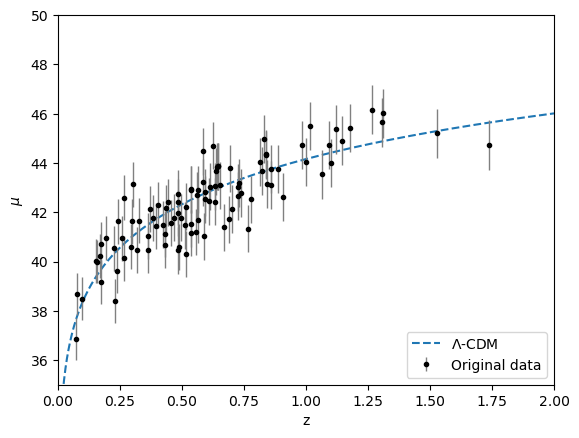

In [37]:
z_grid = np.linspace(0.0, 2.0, 1000)
H_0 = 67.8
Omega_m = 0.308

mu_model = mu_LCDM(z_grid, H_0, Omega_m) 

plt.plot(z_grid, mu_model, color="C0", linestyle='--', label=r"$\Lambda$-CDM")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Original data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

Let's see if we can obtain something similar through MCMC:

In [38]:
def logLikelihood(theta, z, mu, dmu):
    H_0, Omega_m = theta
    mu_model = mu_LCDM(z, H_0, Omega_m)
    return -0.5*np.sum(((mu-mu_model)/dmu)**2 + np.log(2*np.pi*dmu**2))

def logPriors(theta):
    H_0, Omega_m = theta
    if 50 < H_0 < 90 and 0.0 < Omega_m < 1.0:
        return 0.0
    return -np.inf

def logPost(theta, z, mu, dmu):
    lp = logPriors(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta, z, mu, dmu)

In [39]:
ndim = 2
nwalkers = 5  
nsteps = 10000
theta_test = 73, 0.3

starting_guesses = theta_test + 1e-4*np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, logPost, args=[z_sample, mu_sample, dmu])
sampler.run_mcmc(starting_guesses, nsteps, progress=True)
print("done")

100%|██████████| 10000/10000 [02:19<00:00, 71.52it/s]


done


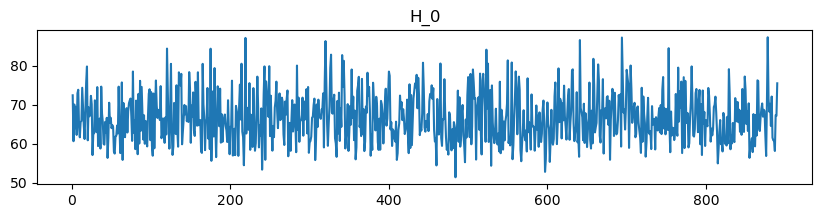

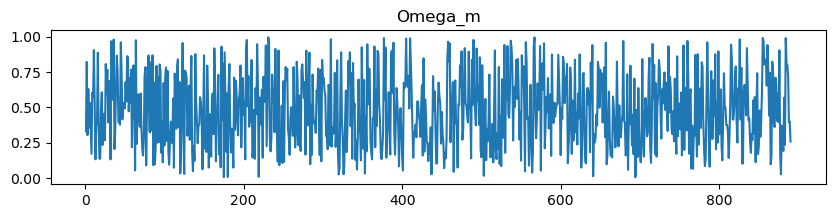

In [40]:
tau = sampler.get_autocorr_time()
thin = int(np.max(tau))
burn = 3*thin

emcee_trace_thin = sampler.get_chain(discard = burn, flat=True, thin=thin)

size = len(emcee_trace_thin[:,0])
X = np.linspace(1, size, size)
labels = ['H_0', 'Omega_m']

for i in range(len(labels)):
   plt.figure(figsize = (10, 2))
   plt.plot(X, emcee_trace_thin[:, i])
   plt.title(labels[i])

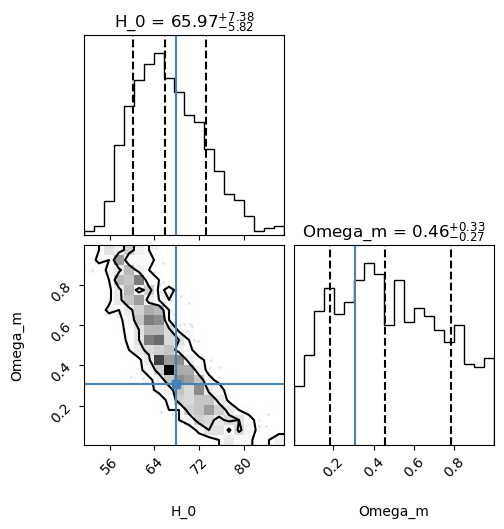

In [41]:
fig = corner.corner(emcee_trace_thin, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], truths=[H_0, Omega_m], show_titles=True)

H_0_DE = np.median(emcee_trace_thin[:,0])
Omega_m_DE = np.median(emcee_trace_thin[:,1])

For both parameters, the fiducial values lie in the 68% confidence interval! We can also see that $H_0$ and $\Omega_m$ are correlated.

Let's see what happens if we don't consider dark energy:

In [42]:
def mu_LCDM_noDE(z, H_0):

    def integral(zp):
        return 1.0 / np.sqrt(Omega_m*(1+zp)**3 + (1-Omega_m))

    mu = np.zeros_like(z, dtype=float)
    for i, zi in enumerate(z):
        I, _ = quad(integral, 0, zi)
        mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)

    return mu

def logLikelihood_noDE(theta, z, mu, dmu):
    H_0 = theta
    mu_model = mu_LCDM_noDE(z, H_0)
    return -0.5*np.sum(((mu-mu_model)/dmu)**2 + np.log(2*np.pi*dmu**2))

def logPriors_noDE(theta):
    H_0 = theta
    if 40.0 < H_0 < 80.0:
        return 0.0
    return -np.inf


def logPost_noDE(theta, z, mu, dmu):
    lp = logPriors_noDE(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood_noDE(theta, z, mu, dmu)

In [43]:
ndim = 1
nwalkers = 5  
nsteps = 10000
theta_test = 73
Omega_m = 1.0

starting_guesses = theta_test + 1e-4*np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, logPost_noDE, args=[z_sample, mu_sample, dmu])
sampler.run_mcmc(starting_guesses, nsteps, progress=True)
print("done")

C:\Users\aless\AppData\Local\Temp\ipykernel_20132\1013102738.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)
100%|██████████| 10000/10000 [03:58<00:00, 41.97it/s]

done


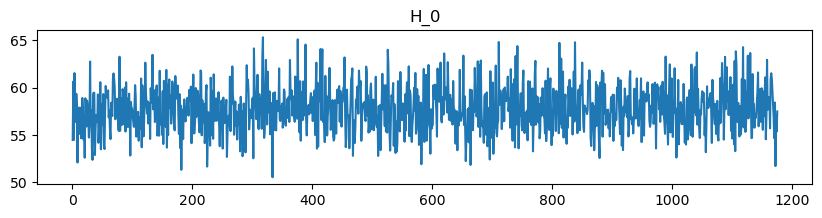

In [44]:
tau = sampler.get_autocorr_time()
thin = int(np.max(tau))
burn = 3*thin

emcee_trace_thin = sampler.get_chain(discard = burn, flat=True, thin=thin)

size = len(emcee_trace_thin[:,0])
X = np.linspace(1, size, size)
labels = ['H_0']

for i in range(len(labels)):
   plt.figure(figsize = (10, 2))
   plt.plot(X, emcee_trace_thin[:, i])
   plt.title(labels[i])

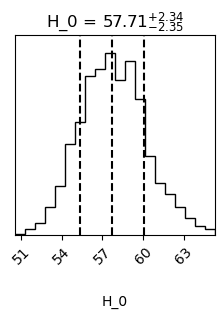

In [45]:
emcee_trace_thin = emcee_trace_thin.reshape(-1, 1)
fig = corner.corner(emcee_trace_thin, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)

H_0_noDE = np.median(emcee_trace_thin)

Let's overplot these two models on our data and see which one is the best:

C:\Users\aless\AppData\Local\Temp\ipykernel_20132\1533589486.py:11: RuntimeWarning: divide by zero encountered in log10
  mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)
C:\Users\aless\AppData\Local\Temp\ipykernel_20132\1013102738.py:9: RuntimeWarning: divide by zero encountered in log10
  mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)


(35.0, 50.0)

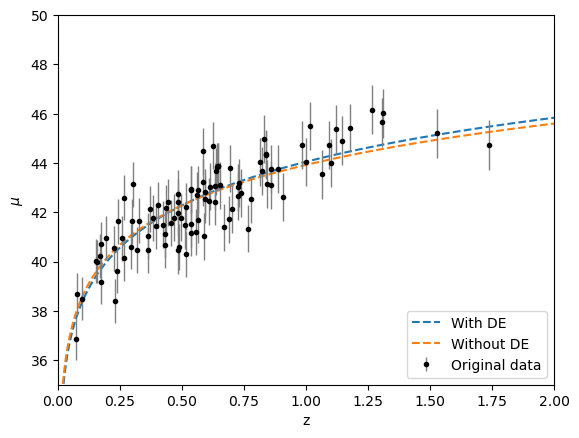

In [46]:
z_grid = np.linspace(0.0, 2.0, 1000)

mu_model_DE = mu_LCDM(z_grid, H_0_DE, Omega_m_DE) 
mu_model_noDE = mu_LCDM_noDE(z_grid, H_0_noDE)

plt.plot(z_grid, mu_model_DE, color="C0", linestyle='--', label='With DE')
plt.plot(z_grid, mu_model_noDE, color="C1", linestyle='--', label="Without DE")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Original data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

It's not easy to distinguish by eye which of the model is the best since they look pretty similar. 

If we want to compare the two models, we can use the Bayes factor. Still we need the evidence, which we can obtain through nested sampling:

In [47]:
def mu_LCDM_DE(z, H_0, Omega_m):

    def integral(zp):
        return 1.0 / np.sqrt(Omega_m*(1+zp)**3 + (1-Omega_m))

    mu = np.zeros_like(z, dtype=float)
    for i, zi in enumerate(z):
        I, _ = quad(integral, 0, zi)
        mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)

    return mu

def logLikelihood_DE(theta, z, mu, dmu):
    H_0, Omega_m = theta
    mu_model = mu_LCDM_DE(z, H_0, Omega_m)
    return -0.5*np.sum(((mu-mu_model)/dmu)**2 + np.log(2*np.pi*dmu**2))

def logPriors_DE(theta):
    H_0, Omega_m = theta
    prior_H_0 = stats.uniform.ppf(H_0, loc = 40, scale = 40)
    prior_Omega_m = stats.uniform.ppf(Omega_m, loc = 0.0, scale =1)
    return np.array([prior_H_0, prior_Omega_m])

In [48]:
n_dim_DE = 2
sampler_DE = dynesty.NestedSampler(logLikelihood_DE, logPriors_DE, n_dim_DE, 
                                 logl_args=[z_sample, mu_sample, dmu],
                                 nlive=500)
sampler_DE.run_nested()
res_DE = sampler_DE.results
evidence_DE = np.exp(res_DE.logz[-1])

1425it [00:33, 42.97it/s, +500 | bound: 0 | nc: 1 | ncall: 9381 | eff(%): 21.675 | loglstar:   -inf < -132.814 <    inf | logz: -134.801 +/-  0.035 | dlogz:  0.001 >  0.509]


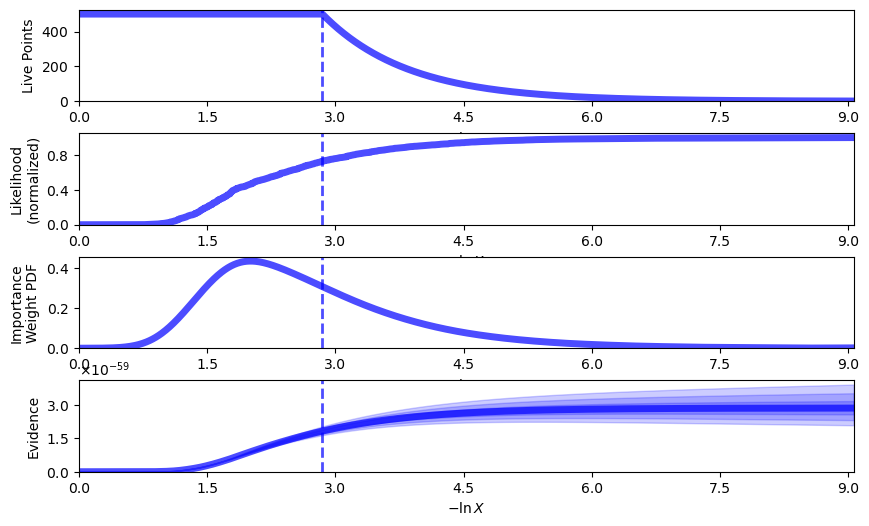

In [49]:
rfig, raxes = dyplot.runplot(res_DE)
rfig.set_size_inches(10, 6)
rfig.subplots_adjust(hspace=0.35) # just so they don't overlap

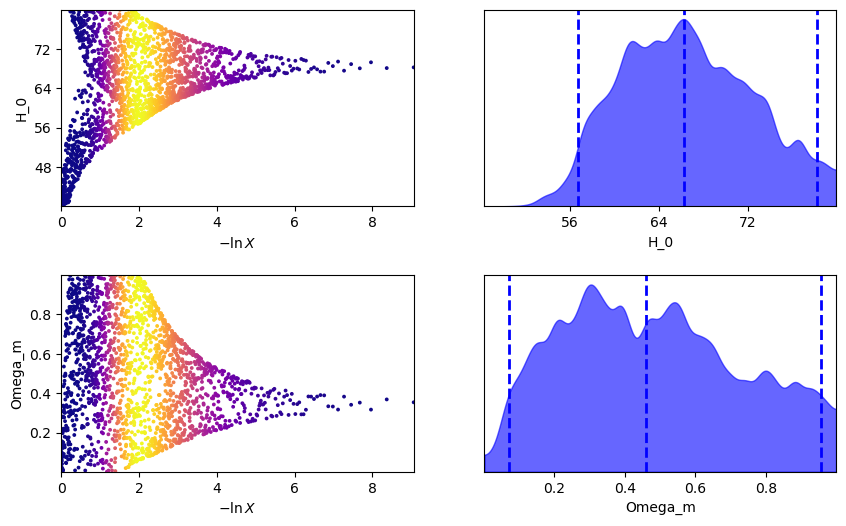

In [50]:
labels = ['H_0', 'Omega_m']
cfig, taxes = dyplot.traceplot(res_DE, labels=labels)
cfig.set_size_inches(10, 6)
cfig.subplots_adjust(hspace=0.35) # just so they don't overlap

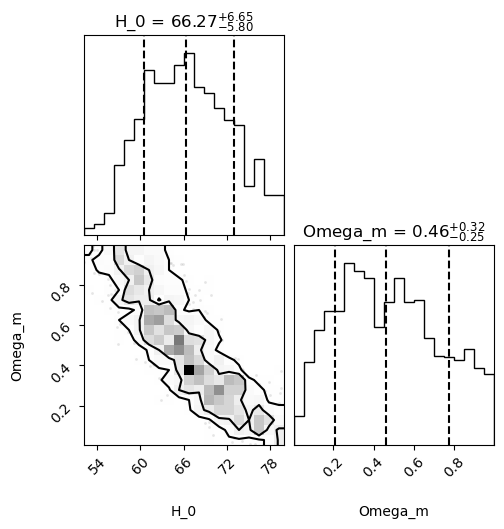

In [51]:
samples_DE = res_DE.samples
weights_DE = np.exp(res_DE.logwt - res_DE.logz[-1])

samples_DE_new = dyfunc.resample_equal(samples_DE, weights_DE)

fig = corner.corner(samples_DE_new, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)

In [52]:
def mu_LCDM_noDE(z, H_0):
    Omega_m = 1.0
    def integral(zp):
        return 1.0 / np.sqrt(Omega_m*(1+zp)**3 + (1-Omega_m))

    mu = np.zeros_like(z, dtype=float)
    for i, zi in enumerate(z):
        I, _ = quad(integral, 0, zi)
        mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)
    return mu

def logLikelihood_noDE(theta, z, mu, dmu):
    H_0 = theta
    mu_model = mu_LCDM_noDE(z, H_0)
    return -0.5*np.sum(((mu-mu_model)/dmu)**2 + np.log(2*np.pi*dmu**2))

def logPriors_noDE(theta):
    H_0 = theta
    prior_H_0 = stats.uniform.ppf(H_0, loc = 40, scale = 40)
    return prior_H_0

In [53]:
n_dim_noDE = 1

sampler_noDE = dynesty.NestedSampler(logLikelihood_noDE, logPriors_noDE, n_dim_noDE, 
                                 logl_args=[z_sample, mu_sample, dmu],
                                 nlive=500)
sampler_noDE.run_nested()
res_noDE = sampler_noDE.results
evidence_noDE = np.exp(res_noDE.logz[-1])

C:\Users\aless\AppData\Local\Temp\ipykernel_20132\91256923.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu[i] = 5 * np.log10((c/H_0) * (1+zi) * I * 1e6 / 10.0)
1355it [00:27, 49.71it/s, +500 | bound: 0 | nc: 1 | ncall: 8316 | eff(%): 23.733 | loglstar:   -inf < -133.530 <    inf | logz: -135.334 +/-  0.022 | dlogz:  0.001 >  0.509]


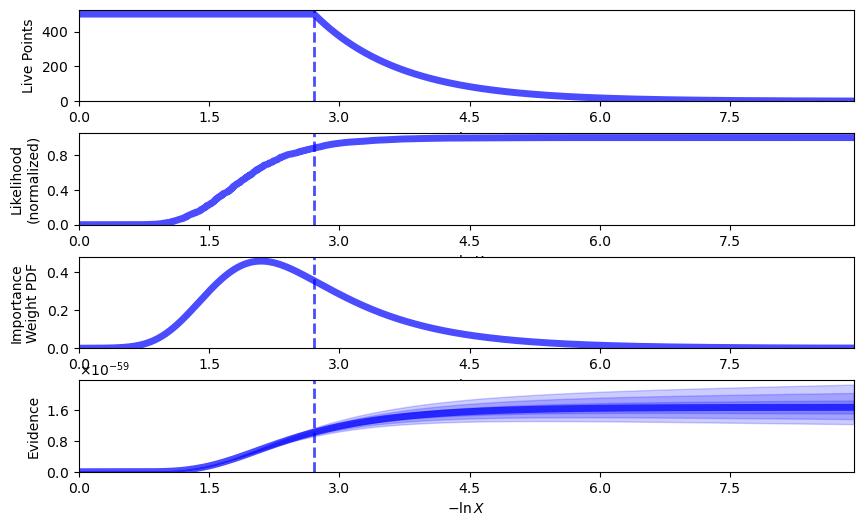

In [54]:
rfig, raxes = dyplot.runplot(res_noDE)
rfig.set_size_inches(10, 6)
rfig.subplots_adjust(hspace=0.35) # just so they don't overlap

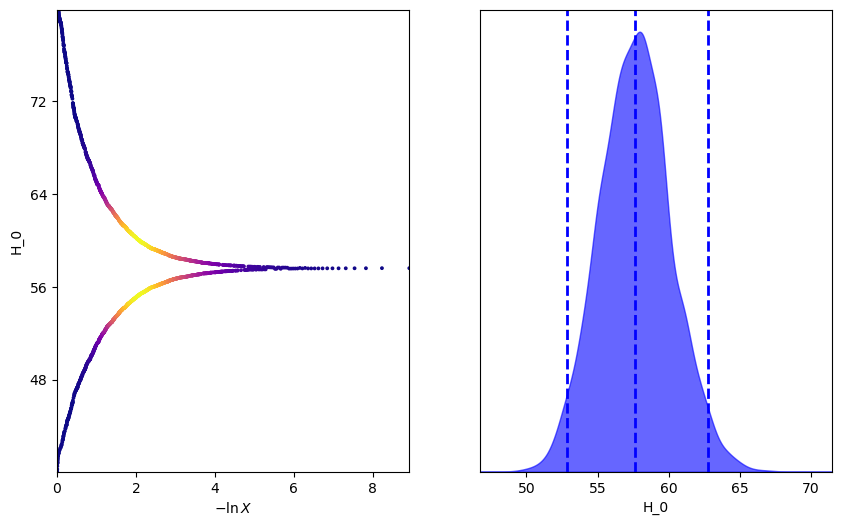

In [55]:
labels = ['H_0']
cfig, taxes = dyplot.traceplot(res_noDE, labels=labels)
cfig.set_size_inches(10, 6)
cfig.subplots_adjust(hspace=0.35) # just so they don't overlap

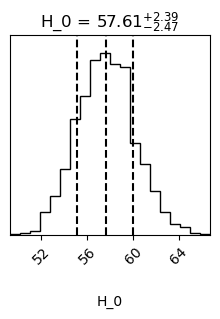

In [56]:
samples_noDE = res_noDE.samples
weights_noDE = np.exp(res_noDE.logwt - res_noDE.logz[-1])

samples_noDE_new = dyfunc.resample_equal(samples_noDE, weights_noDE)

fig = corner.corner(samples_noDE_new, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)

In [57]:
B = evidence_DE / evidence_noDE
print(f"DE vs no DE Bayes factor: {B:.2f}")

DE vs no DE Bayes factor: 1.70


The Bayes factor slightly prefers the model with dark energy. However, this value is too small to claim a detection and, according to the Jeffreys scale, is classified as barely worth mentioning.